In [2]:
%pip install matplotlib seaborn scipy

^C
Note: you may need to restart the kernel to use updated packages.


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.3 MB 11.7 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.3 MB 11.7 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.3 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 11.3 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   -- ------------------------------------- 2.4/37.3 MB 11.6 MB/s eta 0:00:03
   ----- ---------------------------------- 5.0/37.3 MB 11.7 MB/s eta 0:00:03
   ------- -------------------------------- 7.3/37.3 MB 11.7 MB/s eta 0:00:03
   ---------- ----------------------------- 9.7/37.3 MB 11.7 MB/s eta 0:00:03
   ------------- -------------------------- 12.3/37.3 MB 11.7 MB/s eta 0:00:03
   --------------- ------------------------ 14.7/37.3 MB 11.7 MB/s eta 0:00:02
   ------------------ --------------------- 17.3/37.3 MB 11.7 MB/s eta 0:00:02
   ----

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. Lendo os arquivos com o separador correto (vírgula)
# NÃO ESQUEÇA DE AJUSTAR OS NOMES DOS ARQUIVOS ABAIXO:
df_clima = pd.read_csv('../data/raw/inmet_vitoria_clima_consolidado_2021_2025.csv', sep=',') 
df_desmatamento = pd.read_csv('../data/raw/mapbiomas_vitoria_agregado_2021_2024.csv', sep=',')

# 2. Transformando a coluna DATA em formato de tempo e extraindo o ANO
df_clima['DATA'] = pd.to_datetime(df_clima['DATA'])
df_clima['ANO'] = df_clima['DATA'].dt.year

# 3. Agora sim, o Merge vai funcionar porque ambas têm a coluna 'ANO'!
df_merged = pd.merge(df_clima, df_desmatamento, on='ANO', how='inner')

# Mostrar as colunas para confirmar o sucesso
display(df_merged.head())

,DATA,CHUVA,TEMP_MAX,TEMP_MIN,TEMP_MEDIA,ANO,AREA_DESMATADA_HA
0,2021-01-01,0.0,34.4,20.9,26.519048,2021,3.779856
1,2021-01-02,0.0,33.1,21.7,26.583333,2021,3.779856
2,2021-01-03,8.2,28.6,22.7,25.095000,2021,3.779856
3,2021-01-04,1.4,29.7,22.9,24.952174,2021,3.779856
4,2021-01-05,0.0,32.8,22.9,27.558333,2021,3.779856


In [2]:
# Inspecionando o nome exato das colunas nas duas tabelas
print("Colunas do Clima:", df_clima.columns.tolist())
print("\nColunas do Desmatamento:", df_desmatamento.columns.tolist())

Colunas do Clima: ['DATA,CHUVA,TEMP_MAX,TEMP_MIN,TEMP_MEDIA']

Colunas do Desmatamento: ['ANO,AREA_DESMATADA_HA']


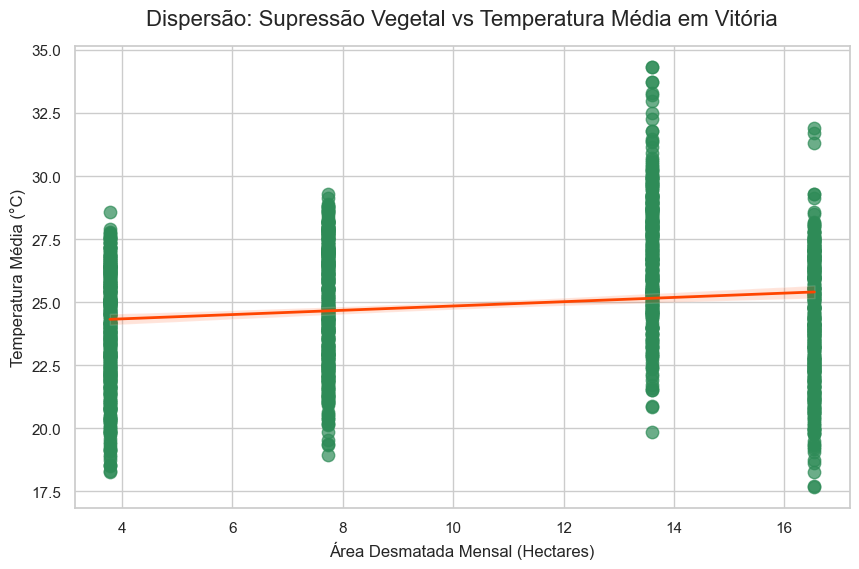

--------------------------------------------------
📈 Coeficiente de Correlação (r): 0.157
🎯 P-valor (Significância): 0.0000
--------------------------------------------------


In [8]:
# 1. Configurar o estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Criar o Scatter Plot com a Linha de Tendência
sns.regplot(
    data=df_merged, 
    x='AREA_DESMATADA_HA', # Confirme se o nome da coluna está escrito exatamente assim
    y='TEMP_MEDIA',        # Confirme se o nome da coluna está escrito exatamente assim
    scatter_kws={'alpha': 0.7, 'color': '#2E8B57', 's': 80},
    line_kws={'color': '#FF4500', 'linewidth': 2} 
)

# 3. Textos do gráfico
plt.title('Dispersão: Supressão Vegetal vs Temperatura Média em Vitória', fontsize=16, pad=15)
plt.xlabel('Área Desmatada Mensal (Hectares)', fontsize=12)
plt.ylabel('Temperatura Média (°C)', fontsize=12)
plt.show()

# 4. A Prova Matemática: Cálculo da Correlação de Pearson (Agora com limpeza!)

# Criamos um DataFrame temporário só com as linhas que TÊM dados válidos nas duas colunas
df_limpo = df_merged.dropna(subset=['AREA_DESMATADA_HA', 'TEMP_MEDIA'])

# Agora passamos os dados limpos para a fórmula
correlacao, p_valor = pearsonr(df_limpo['AREA_DESMATADA_HA'], df_limpo['TEMP_MEDIA'])

print("-" * 50)
print(f"📈 Coeficiente de Correlação (r): {correlacao:.3f}")
print(f"🎯 P-valor (Significância): {p_valor:.4f}")
print("-" * 50)